Saved: death_of_v8_eda.png


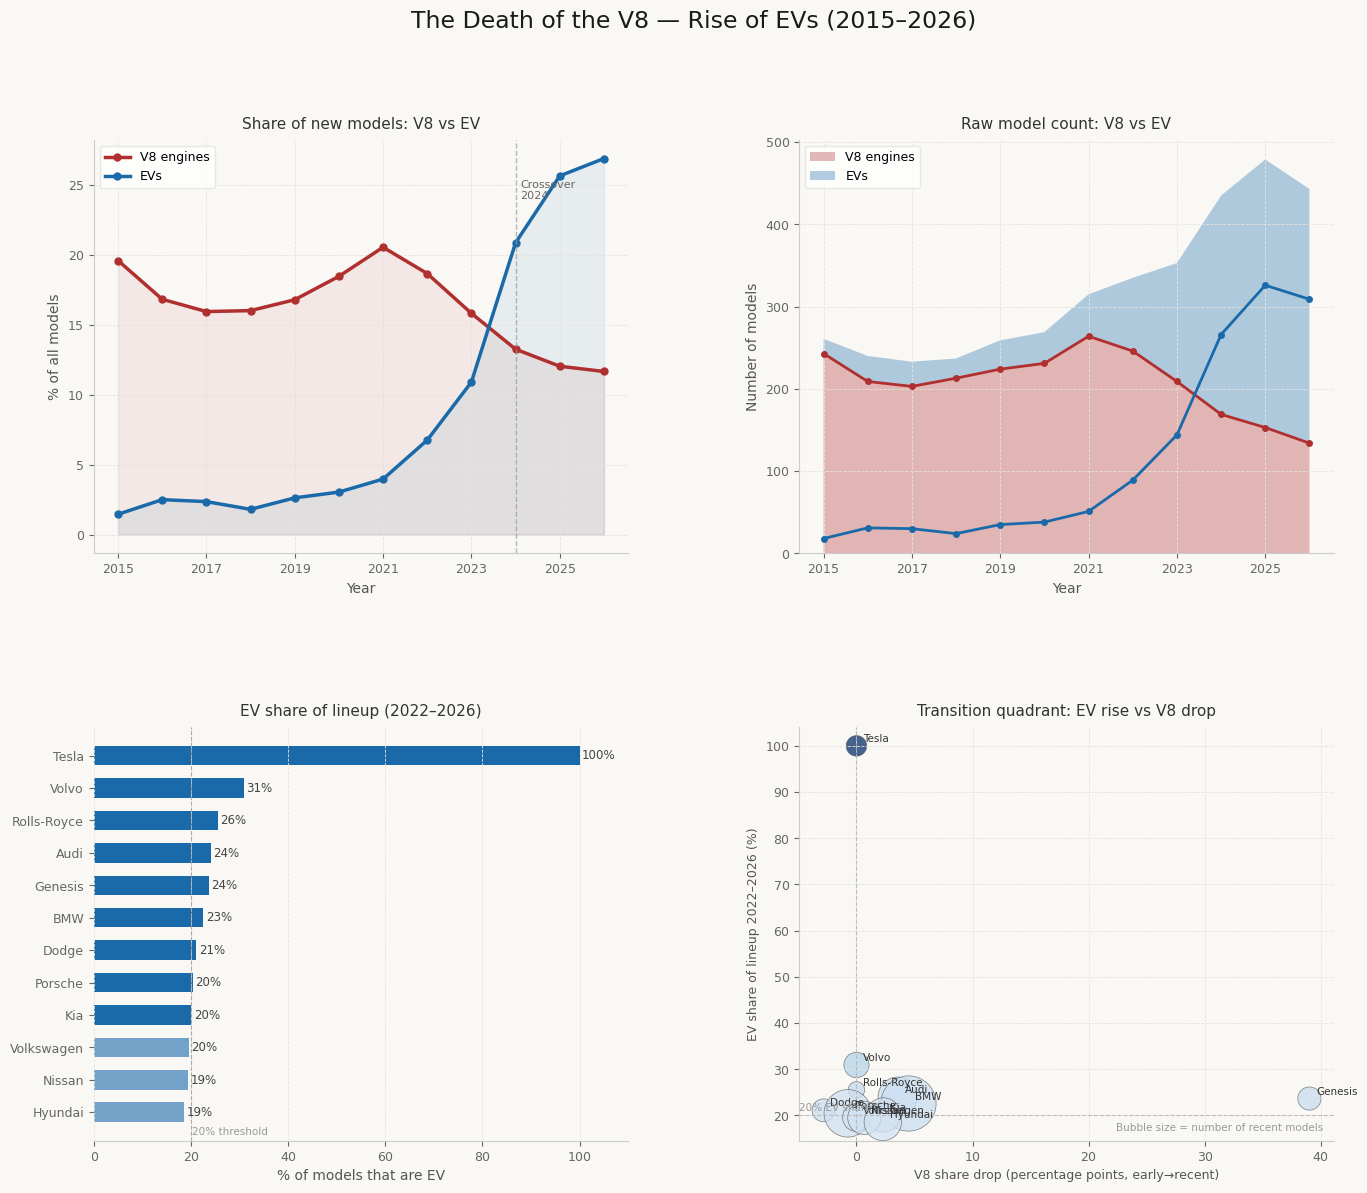

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

CSV_PATH = os.path.expanduser("~/Downloads/EV_vs_ICE_Vehicle_Specs_2015_2026.csv")

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# ── Derived series ─────────────────────────────────────────────────────────
years = sorted(df["Year"].unique())
total_by_year = df.groupby("Year").size()

v8_by_year  = df[df["Engine_Cylinders"] == 8].groupby("Year").size()
ev_by_year  = df[df["Vehicle_Category"] == "EV"].groupby("Year").size()

v8_pct = (v8_by_year / total_by_year * 100).reindex(years, fill_value=0)
ev_pct = (ev_by_year / total_by_year * 100).reindex(years, fill_value=0)

# ── Manufacturer transition score ──────────────────────────────────────────
# EV share (2022-2026) vs V8 drop (early minus recent share)
early  = df[df["Year"] <= 2018]
recent = df[df["Year"] >= 2022]
common_makes = set(recent["Make"].unique()) & set(early["Make"].unique())

rows = []
for make in common_makes:
    r = recent[recent["Make"] == make]
    e = early[early["Make"] == make]
    if len(r) < 20:
        continue
    ev_share   = (r["Vehicle_Category"] == "EV").mean() * 100
    v8_early   = (e["Engine_Cylinders"] == 8).mean() * 100
    v8_recent  = (r["Engine_Cylinders"] == 8).mean() * 100
    v8_drop    = v8_early - v8_recent
    rows.append({"Make": make, "EV Share (%)": ev_share,
                 "V8 Drop (pp)": v8_drop, "n": len(r)})

transition = (pd.DataFrame(rows)
              .sort_values("EV Share (%)", ascending=False)
              .head(12)
              .reset_index(drop=True))

# ── EV vs V8 per manufacturer (recent years only) ──────────────────────────
top_makes = transition["Make"].tolist()
ev_counts  = (df[(df["Vehicle_Category"] == "EV") & df["Make"].isin(top_makes)]
              .groupby("Make").size().reindex(top_makes, fill_value=0))
v8_counts  = (df[(df["Engine_Cylinders"] == 8) & df["Make"].isin(top_makes)]
              .groupby("Make").size().reindex(top_makes, fill_value=0))

# ── Plot ───────────────────────────────────────────────────────────────────
BLUE   = "#1a6aaa"
RED    = "#b03030"
ORANGE = "#d4700a"
BG     = "#f9f8f5"
GRID   = "#e4e3de"

fig = plt.figure(figsize=(16, 13), facecolor=BG)
fig.suptitle("The Death of the V8 — Rise of EVs (2015–2026)",
             fontsize=17, fontweight="normal", color="#1a1a18", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── Panel 1: % share over time ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(BG)
ax1.plot(years, v8_pct.values,  color=RED,  linewidth=2.5,
         marker="o", markersize=5, label="V8 engines")
ax1.plot(years, ev_pct.values,  color=BLUE, linewidth=2.5,
         marker="o", markersize=5, label="EVs")
ax1.fill_between(years, v8_pct.values, alpha=0.08, color=RED)
ax1.fill_between(years, ev_pct.values, alpha=0.08, color=BLUE)

# Crossover annotation
cross_yr = None
for i in range(len(years)-1):
    if ev_pct.values[i] < v8_pct.values[i] and ev_pct.values[i+1] >= v8_pct.values[i+1]:
        cross_yr = years[i+1]
if cross_yr:
    ax1.axvline(cross_yr, color="#999", linewidth=1, linestyle="--", alpha=0.7)
    ax1.text(cross_yr + 0.1, ax1.get_ylim()[1]*0.85,
             f"Crossover\n{cross_yr}", fontsize=8, color="#666")

ax1.set_title("Share of new models: V8 vs EV", fontsize=11, color="#333", pad=8)
ax1.set_xlabel("Year", fontsize=10, color="#555")
ax1.set_ylabel("% of all models", fontsize=10, color="#555")
ax1.legend(fontsize=9, framealpha=0.8, edgecolor=GRID)
ax1.grid(color=GRID, linewidth=0.6, linestyle="--")
ax1.spines[["top","right"]].set_visible(False)
ax1.spines[["left","bottom"]].set_color("#ccc")
ax1.tick_params(colors="#666", labelsize=9)
ax1.set_xticks(years[::2])

# ── Panel 2: Raw counts stacked area ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(BG)
ax2.stackplot(years,
              v8_by_year.reindex(years, fill_value=0).values,
              ev_by_year.reindex(years, fill_value=0).values,
              labels=["V8 engines", "EVs"],
              colors=[RED+"55", BLUE+"55"],
              baseline="zero")
ax2.plot(years, v8_by_year.reindex(years, fill_value=0).values,
         color=RED,  linewidth=2, marker="o", markersize=4)
ax2.plot(years, ev_by_year.reindex(years, fill_value=0).values,
         color=BLUE, linewidth=2, marker="o", markersize=4)
ax2.set_title("Raw model count: V8 vs EV", fontsize=11, color="#333", pad=8)
ax2.set_xlabel("Year", fontsize=10, color="#555")
ax2.set_ylabel("Number of models", fontsize=10, color="#555")
ax2.legend(fontsize=9, framealpha=0.8, edgecolor=GRID)
ax2.grid(color=GRID, linewidth=0.6, linestyle="--")
ax2.spines[["top","right"]].set_visible(False)
ax2.spines[["left","bottom"]].set_color("#ccc")
ax2.tick_params(colors="#666", labelsize=9)
ax2.set_xticks(years[::2])

# ── Panel 3: Manufacturer EV share bar chart ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(BG)

makes_sorted = transition.sort_values("EV Share (%)", ascending=True)
colors_bar = [BLUE if v >= 20 else BLUE+"99" for v in makes_sorted["EV Share (%)"]]
bars = ax3.barh(makes_sorted["Make"], makes_sorted["EV Share (%)"],
                color=colors_bar, height=0.6, edgecolor="none")

for bar, val in zip(bars, makes_sorted["EV Share (%)"]):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.0f}%", va="center", fontsize=8.5, color="#444")

ax3.axvline(20, color="#aaa", linewidth=0.8, linestyle="--")
ax3.text(20.3, -0.7, "20% threshold", fontsize=7.5, color="#999")
ax3.set_title("EV share of lineup (2022–2026)", fontsize=11, color="#333", pad=8)
ax3.set_xlabel("% of models that are EV", fontsize=10, color="#555")
ax3.grid(axis="x", color=GRID, linewidth=0.6, linestyle="--")
ax3.spines[["top","right","left"]].set_visible(False)
ax3.spines["bottom"].set_color("#ccc")
ax3.tick_params(colors="#666", labelsize=9)
ax3.set_xlim(0, makes_sorted["EV Share (%)"].max() + 10)

# ── Panel 4: EV vs V8 bubble scatter per manufacturer ─────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(BG)

x = transition["V8 Drop (pp)"]
y = transition["EV Share (%)"]
sizes = transition["n"] * 3

sc = ax4.scatter(x, y, s=sizes, alpha=0.75,
                 c=y, cmap="Blues", edgecolors="#555", linewidths=0.5,
                 vmin=0, vmax=y.max())

for _, row in transition.iterrows():
    ax4.annotate(row["Make"],
                 xy=(row["V8 Drop (pp)"], row["EV Share (%)"]),
                 xytext=(5, 3), textcoords="offset points",
                 fontsize=7.5, color="#333")

ax4.axhline(20, color="#aaa", linewidth=0.8, linestyle="--", alpha=0.7)
ax4.axvline(0,  color="#aaa", linewidth=0.8, linestyle="--", alpha=0.7)
ax4.text(ax4.get_xlim()[0] if ax4.get_xlim()[0] > -50 else -5,
         21, "20% EV share", fontsize=7.5, color="#999")

ax4.set_title("Transition quadrant: EV rise vs V8 drop", fontsize=11, color="#333", pad=8)
ax4.set_xlabel("V8 share drop (percentage points, early→recent)", fontsize=9, color="#555")
ax4.set_ylabel("EV share of lineup 2022–2026 (%)", fontsize=9, color="#555")
ax4.grid(color=GRID, linewidth=0.6, linestyle="--")
ax4.spines[["top","right"]].set_visible(False)
ax4.spines[["left","bottom"]].set_color("#ccc")
ax4.tick_params(colors="#666", labelsize=9)

note = "Bubble size = number of recent models"
ax4.text(0.98, 0.02, note, transform=ax4.transAxes,
         fontsize=7.5, color="#999", ha="right", va="bottom")

plt.savefig("death_of_v8_eda.png", dpi=150, bbox_inches="tight",
            facecolor=BG)
print("Saved: death_of_v8_eda.png")
plt.show()